# Task 4 — Dimensionality Reduction & Unsupervised Clustering

## Objective

The objective of this task is to apply dimensionality reduction and unsupervised clustering techniques to identify patterns in high-dimensional numerical data.

## Dataset

The Scikit-learn Wine dataset is used for this analysis.

The dataset contains 13 numerical features representing chemical properties of wines.

## Techniques

### Dimensionality Reduction
- Feature Standardization
- Principal Component Analysis (PCA)
- Explained Variance Ratio
- PCA Scree Plot

### Clustering
- K-Means Clustering
- Elbow Method
- Silhouette Score
- DBSCAN
- Hierarchical Clustering

### Visualization
- 2D PCA Cluster Visualization
- 3D PCA Cluster Visualization

## Significance

PCA is used to reduce the dimensionality of the dataset while retaining important information. Clustering algorithms are then applied to identify groups and patterns within the transformed data.

In [1]:
# Import libraries and load the Wine dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine

sns.set_theme(style="whitegrid")

wine = load_wine()

df = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Features:", df.shape[1])

print("\nFeature names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
Rows: 178
Features: 13

Feature names:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Missing values:
0

First 5 rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [2]:
# Standardize the numerical features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=df.columns
)

print("Standardization completed successfully!")
print("Shape:", X_scaled_df.shape)

print("\nMean after standardization:")
print(X_scaled_df.mean().round(4))

print("\nStandard deviation after standardization:")
print(X_scaled_df.std(ddof=0).round(4))

Standardization completed successfully!
Shape: (178, 13)

Mean after standardization:
alcohol                        -0.0
malic_acid                     -0.0
ash                            -0.0
alcalinity_of_ash              -0.0
magnesium                      -0.0
total_phenols                   0.0
flavanoids                     -0.0
nonflavanoid_phenols            0.0
proanthocyanins                -0.0
color_intensity                 0.0
hue                             0.0
od280/od315_of_diluted_wines    0.0
proline                        -0.0
dtype: float64

Standard deviation after standardization:
alcohol                         1.0
malic_acid                      1.0
ash                             1.0
alcalinity_of_ash               1.0
magnesium                       1.0
total_phenols                   1.0
flavanoids                      1.0
nonflavanoid_phenols            1.0
proanthocyanins                 1.0
color_intensity                 1.0
hue                         

In [3]:
# Apply PCA

from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print("PCA completed successfully!")
print("Original number of features:", X_scaled.shape[1])
print("Number of PCA components:", X_pca.shape[1])

PCA completed successfully!
Original number of features: 13
Number of PCA components: 13


In [4]:
# Explained variance ratio

explained_variance = pca.explained_variance_ratio_

variance_table = pd.DataFrame({
    "Component": range(1, len(explained_variance) + 1),
    "Explained_Variance_Ratio": explained_variance,
    "Cumulative_Variance": np.cumsum(explained_variance)
})

variance_table

,Component,Explained_Variance_Ratio,Cumulative_Variance
0,1,0.361988,0.361988
1,2,0.192075,0.554063
2,3,0.111236,0.665300
3,4,0.070690,0.735990
4,5,0.065633,0.801623
5,6,0.049358,0.850981
6,7,0.042387,0.893368
7,8,0.026807,0.920175
8,9,0.022222,0.942397
9,10,0.019300,0.961697


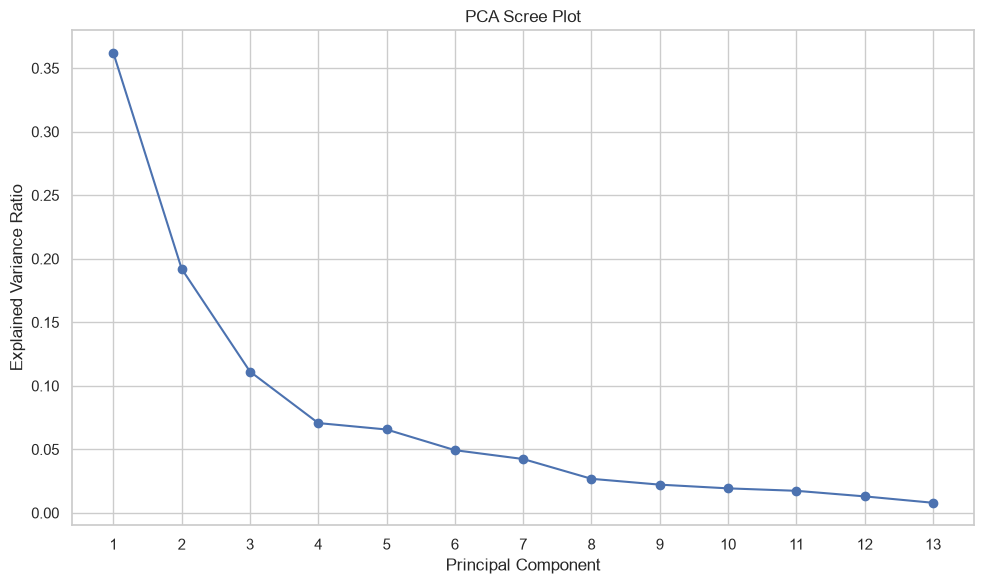

In [5]:
# PCA Scree Plot

plt.figure(figsize=(10, 6))

plt.plot(
    variance_table["Component"],
    variance_table["Explained_Variance_Ratio"],
    marker="o"
)

plt.title("PCA Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.xticks(range(1, 14))
plt.grid(True)

plt.tight_layout()

plt.show()

In [6]:
# Determine the number of components for 95% variance

cumulative_variance = np.cumsum(explained_variance)

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Components needed for 95% variance:", n_components_95)
print(
    "Cumulative variance retained:",
    round(cumulative_variance[n_components_95 - 1], 4)
)

Components needed for 95% variance: 10
Cumulative variance retained: 0.9617


In [7]:
# Create PCA dataset using the selected number of components

pca_reduced = PCA(n_components=n_components_95)

X_pca_reduced = pca_reduced.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca_reduced,
    columns=[
        f"PC{i}"
        for i in range(1, n_components_95 + 1)
    ]
)

print("Reduced PCA dataset created successfully!")
print("Original features:", X_scaled.shape[1])
print("Reduced components:", X_pca_reduced.shape[1])
print("Shape:", X_pca_reduced.shape)

display(pca_df.head())

Reduced PCA dataset created successfully!
Original features: 13
Reduced components: 10
Shape: (178, 10)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,3.316751,1.443463,-0.165739,-0.215631,0.693043,0.223880,0.596427,-0.065139,-0.641443,1.020956
1,2.209465,-0.333393,-2.026457,-0.291358,-0.257655,0.927120,0.053776,-1.024416,0.308847,0.159701
2,2.516740,1.031151,0.982819,0.724902,-0.251033,-0.549276,0.424205,0.344216,1.177834,0.113361
3,3.757066,2.756372,-0.176192,0.567983,-0.311842,-0.114431,-0.383337,-0.643593,-0.052544,0.239413
4,1.008908,0.869831,2.026688,-0.409766,0.298458,0.406520,0.444074,-0.416700,-0.326819,-0.078366


In [8]:
# Elbow Method for K-Means

from sklearn.cluster import KMeans

inertia_values = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_pca_reduced)
    inertia_values.append(kmeans.inertia_)

print("K-Means models evaluated for k = 2 to 10")

K-Means models evaluated for k = 2 to 10


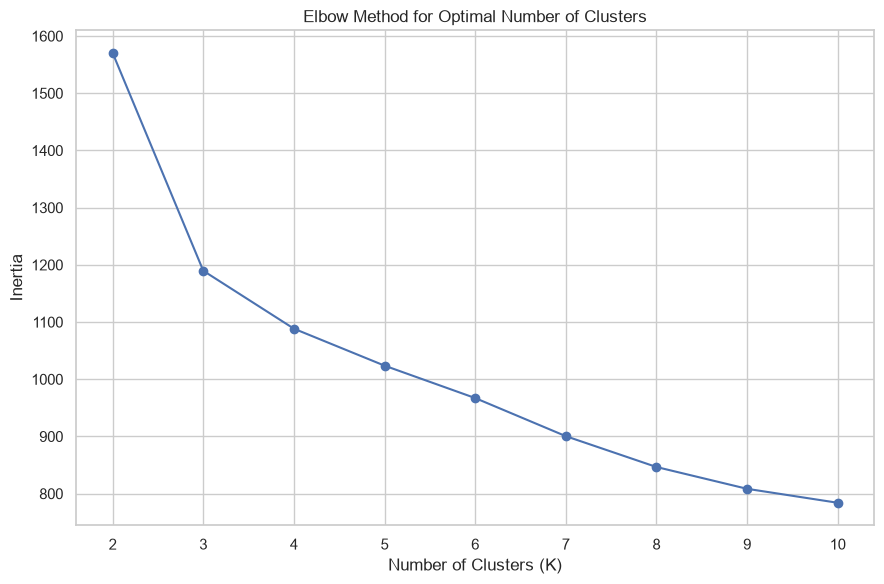

In [9]:
# Elbow Method Plot

plt.figure(figsize=(9, 6))

plt.plot(
    list(k_values),
    inertia_values,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.xticks(list(k_values))
plt.grid(True)

plt.tight_layout()

plt.show()

In [10]:
# Silhouette Score for different K values

from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(X_pca_reduced)
    
    score = silhouette_score(
        X_pca_reduced,
        cluster_labels
    )
    
    silhouette_scores.append(score)

silhouette_table = pd.DataFrame({
    "K": range(2, 11),
    "Silhouette_Score": silhouette_scores
})

silhouette_table

,K,Silhouette_Score
0,2,0.279332
1,3,0.298675
2,4,0.273319
3,5,0.247317
4,6,0.210143
5,7,0.209101
6,8,0.162906
7,9,0.164168
8,10,0.155093


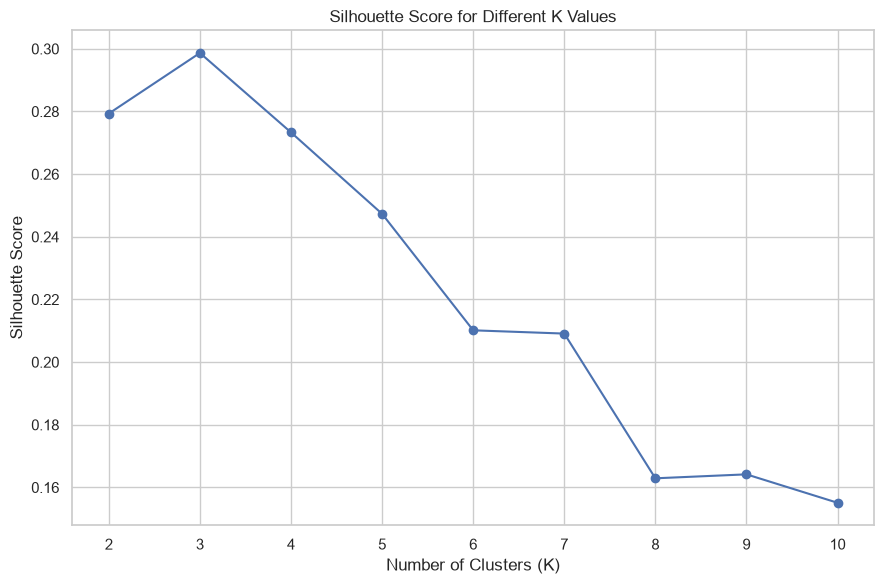

In [11]:
# Silhouette Score Plot

plt.figure(figsize=(9, 6))

plt.plot(
    silhouette_table["K"],
    silhouette_table["Silhouette_Score"],
    marker="o"
)

plt.title("Silhouette Score for Different K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.xticks(range(2, 11))
plt.grid(True)

plt.tight_layout()

plt.show()

In [12]:
# Select the best K using Silhouette Score

best_k = silhouette_table.loc[
    silhouette_table["Silhouette_Score"].idxmax(),
    "K"
]

best_k = int(best_k)

print("Selected K:", best_k)

# Final K-Means model
kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_final.fit_predict(X_pca_reduced)

pca_df["KMeans_Cluster"] = kmeans_labels

print("K-Means clustering completed successfully!")
print("\nCluster counts:")
print(pca_df["KMeans_Cluster"].value_counts().sort_index())

Selected K: 3
K-Means clustering completed successfully!

Cluster counts:
KMeans_Cluster
0    65
1    51
2    62
Name: count, dtype: int64


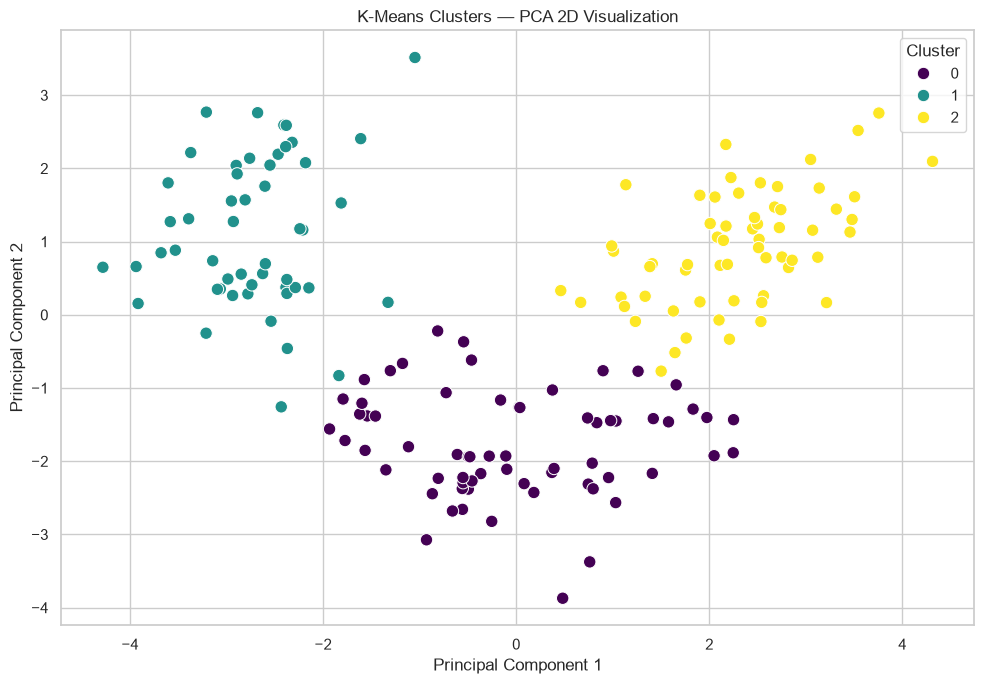

In [13]:
# 2D K-Means Cluster Visualization

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="KMeans_Cluster",
    palette="viridis",
    s=80
)

plt.title("K-Means Clusters — PCA 2D Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")

plt.tight_layout()

plt.show()

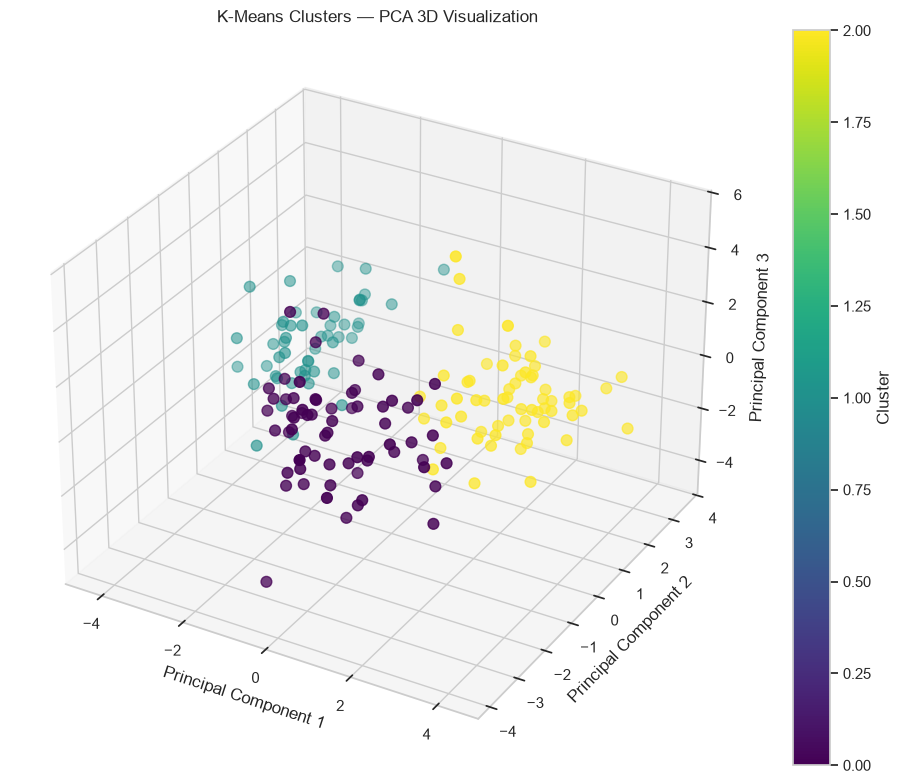

In [14]:
# 3D K-Means Cluster Visualization

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    pca_df["PC3"],
    c=pca_df["KMeans_Cluster"],
    cmap="viridis",
    s=60
)

ax.set_title("K-Means Clusters — PCA 3D Visualization")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")

plt.colorbar(
    scatter,
    ax=ax,
    label="Cluster"
)

plt.tight_layout()
plt.show()

In [15]:
# DBSCAN Clustering

from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_pca_reduced)

pca_df["DBSCAN_Cluster"] = dbscan_labels

print("DBSCAN clustering completed successfully!")

print("\nDBSCAN cluster counts:")
print(pca_df["DBSCAN_Cluster"].value_counts().sort_index())

DBSCAN clustering completed successfully!

DBSCAN cluster counts:
DBSCAN_Cluster
-1    147
 0      5
 1      5
 2      5
 3      5
 4      5
 5      6
Name: count, dtype: int64


Hierarchical clustering completed successfully!

Cluster counts:
Hierarchical_Cluster
0    56
1    66
2    56
Name: count, dtype: int64


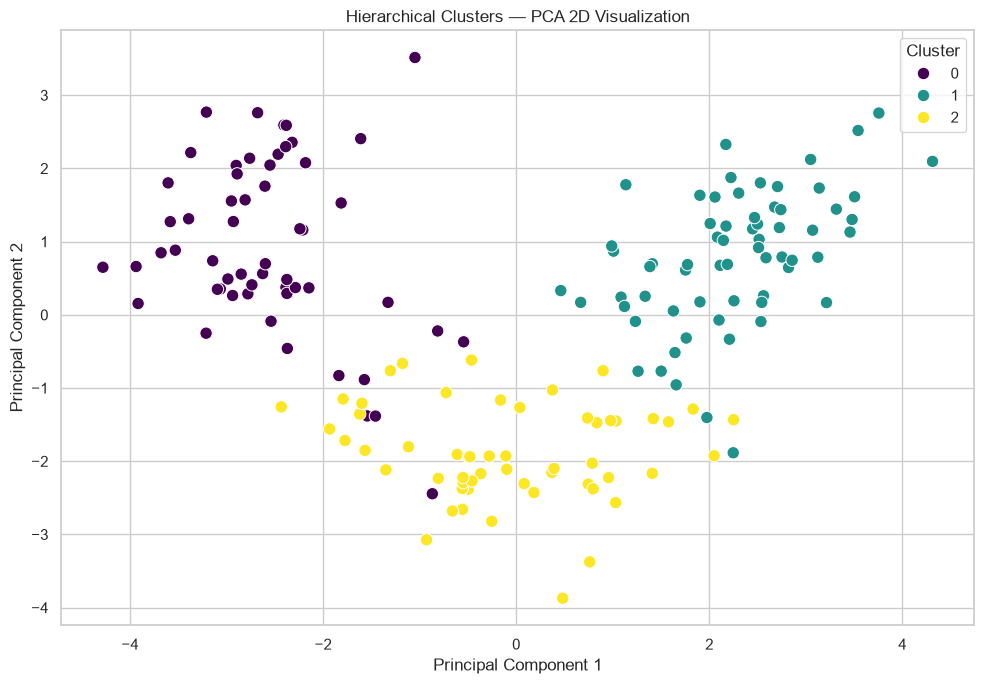

In [16]:
# Hierarchical Clustering and 2D Visualization

from sklearn.cluster import AgglomerativeClustering

# Create hierarchical clustering labels
hierarchical = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(X_pca_reduced)

# Add labels to PCA dataframe
pca_df["Hierarchical_Cluster"] = hierarchical_labels

print("Hierarchical clustering completed successfully!")
print("\nCluster counts:")
print(
    pca_df["Hierarchical_Cluster"]
    .value_counts()
    .sort_index()
)

# Visualization
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=pca_df["PC1"],
    y=pca_df["PC2"],
    hue=pca_df["Hierarchical_Cluster"],
    palette="viridis",
    s=80
)

plt.title("Hierarchical Clusters — PCA 2D Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

In [17]:
# Compare clustering methods

clustering_comparison = pd.DataFrame({
    "Method": [
        "K-Means",
        "DBSCAN",
        "Hierarchical"
    ],
    "Number_of_Clusters": [
        len(np.unique(kmeans_labels)),
        len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0),
        len(np.unique(hierarchical_labels))
    ],
    "Noise_Points": [
        0,
        int(np.sum(dbscan_labels == -1)),
        0
    ]
})

clustering_comparison

,Method,Number_of_Clusters,Noise_Points
0,K-Means,3,0
1,DBSCAN,6,147
2,Hierarchical,3,0


In [18]:
# Save clustering results

from pathlib import Path

results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

pca_df.to_csv(
    results_dir / "task4_clustering_results.csv",
    index=False
)

clustering_comparison.to_csv(
    results_dir / "task4_clustering_comparison.csv",
    index=False
)

print("Clustering results saved successfully!")
print("Files created:")
print("- task4_clustering_results.csv")
print("- task4_clustering_comparison.csv")

Clustering results saved successfully!
Files created:
- task4_clustering_results.csv
- task4_clustering_comparison.csv


In [19]:
# Save PCA and Silhouette results

variance_table.to_csv(
    results_dir / "task4_pca_explained_variance.csv",
    index=False
)

silhouette_table.to_csv(
    results_dir / "task4_silhouette_scores.csv",
    index=False
)

print("PCA and Silhouette results saved successfully!")
print("Files created:")
print("- task4_pca_explained_variance.csv")
print("- task4_silhouette_scores.csv")

PCA and Silhouette results saved successfully!
Files created:
- task4_pca_explained_variance.csv
- task4_silhouette_scores.csv


In [20]:
# Save Task-4 visualizations

plots_dir = Path("../plots")
plots_dir.mkdir(parents=True, exist_ok=True)

# PCA Scree Plot
plt.figure(figsize=(10, 6))
plt.plot(
    variance_table["Component"],
    variance_table["Explained_Variance_Ratio"],
    marker="o"
)
plt.title("PCA Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.xticks(range(1, 14))
plt.grid(True)
plt.tight_layout()
plt.savefig(
    plots_dir / "task4_pca_scree_plot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()

# Elbow Plot
plt.figure(figsize=(9, 6))
plt.plot(
    list(k_values),
    inertia_values,
    marker="o"
)
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.grid(True)
plt.tight_layout()
plt.savefig(
    plots_dir / "task4_elbow_plot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()

# Silhouette Plot
plt.figure(figsize=(9, 6))
plt.plot(
    silhouette_table["K"],
    silhouette_table["Silhouette_Score"],
    marker="o"
)
plt.title("Silhouette Score for Different K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.grid(True)
plt.tight_layout()
plt.savefig(
    plots_dir / "task4_silhouette_plot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()

print("Task-4 visualizations saved successfully!")

Task-4 visualizations saved successfully!


# Final Findings

## PCA Findings

PCA was applied after standardizing the 13 numerical features of the Wine dataset.

The explained variance analysis was used to determine the number of principal components required to retain at least 95% of the total variance.

## K-Means Findings

The Elbow Method and Silhouette Score were used to evaluate different numbers of clusters.

The final K-Means model used the number of clusters selected using the highest Silhouette Score.

## DBSCAN Findings

DBSCAN was applied to the PCA-transformed data to identify clusters and potential noise points.

Points assigned to cluster `-1` were treated as noise by the DBSCAN algorithm.

## Hierarchical Clustering Findings

Agglomerative Hierarchical Clustering was applied using Ward linkage and the selected cluster count.

## Visual Analysis

2D and 3D PCA projections were used to visualize the clustering structure.

The visualizations provide a reduced-dimensional representation of the high-dimensional Wine dataset.

## Reproducibility

The complete analysis was performed in a Jupyter Notebook using Python, Scikit-learn, Pandas, NumPy, Matplotlib, and Seaborn.

The analysis results and visualizations are saved in the `results/` and `plots/` directories.